In [154]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from parcels import ParticleSet
from parcels import JITParticle
from parcels import AdvectionRK4_3D
from parcels import AdvectionRK4
from parcels import Variable
from datetime import timedelta
from parcels import FieldSet

## Parcels on A (bilinear native interpolated) and C grid (calculated)

We are gonna compare the Amazon plume area for 10 days of running particles in COPERNICUS GLORYS by using W native and W calculated. Similar to Nascimento et al., (2025)

* As W calculated is in C grid, it is placed in the middle or T points
* GLORYS data is placed on an A grid, so W,U,V are at the same point


In [306]:
ds = xr.open_dataset(r'../data/cmems_mod_glo_phy-cur_anfc_0.083deg_P1D-m_1752073161915.nc')

In [307]:
ds_w = xr.open_dataset(r'../data/w_plume.nc')

In [308]:
ds['w'] = ds_w.wo
ds = ds.where(ds!=0,np.nan)
ds

<xarray.Dataset> Size: 729MB
Dimensions:    (time: 30, depth: 50, latitude: 241, longitude: 168)
Coordinates:
  * time       (time) datetime64[ns] 240B 2022-06-01 2022-06-02 ... 2022-06-30
  * depth      (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * latitude   (latitude) float32 964B -10.0 -9.917 -9.833 ... 9.833 9.917 10.0
  * longitude  (longitude) float32 672B -55.0 -54.92 -54.83 ... -41.17 -41.08
Data variables:
    uo         (time, depth, latitude, longitude) float32 243MB nan nan ... nan
    vo         (time, depth, latitude, longitude) float32 243MB nan nan ... nan
    w          (time, depth, latitude, longitude) float32 243MB nan nan ... nan
Attributes:
    Conventions:       CF-1.11
    title:             daily mean fields from Global Ocean Physics Analysis a...
    institution:       Mercator Ocean International
    producer:          CMEMS - Global Monitoring and Forecasting Centre
    source:            MOI GLO12
    credit:            E.U. Copernicus Marine Service Information (CMEMS)
    contact:           https://marine.copernicus.eu/contact
    references:        http://marine.copernicus.eu
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  GLOBAL_ANALYSISFORECAST_PHY_001_024
    subset:datasetId:  cmems_mod_glo_phy-cur_anfc_0.083deg_P1D-m_202406
    subset:date:       2025-07-09T14:59:21.915Z

### A grid adequation
* W starting in 0m
* U,V interpolated to 0m

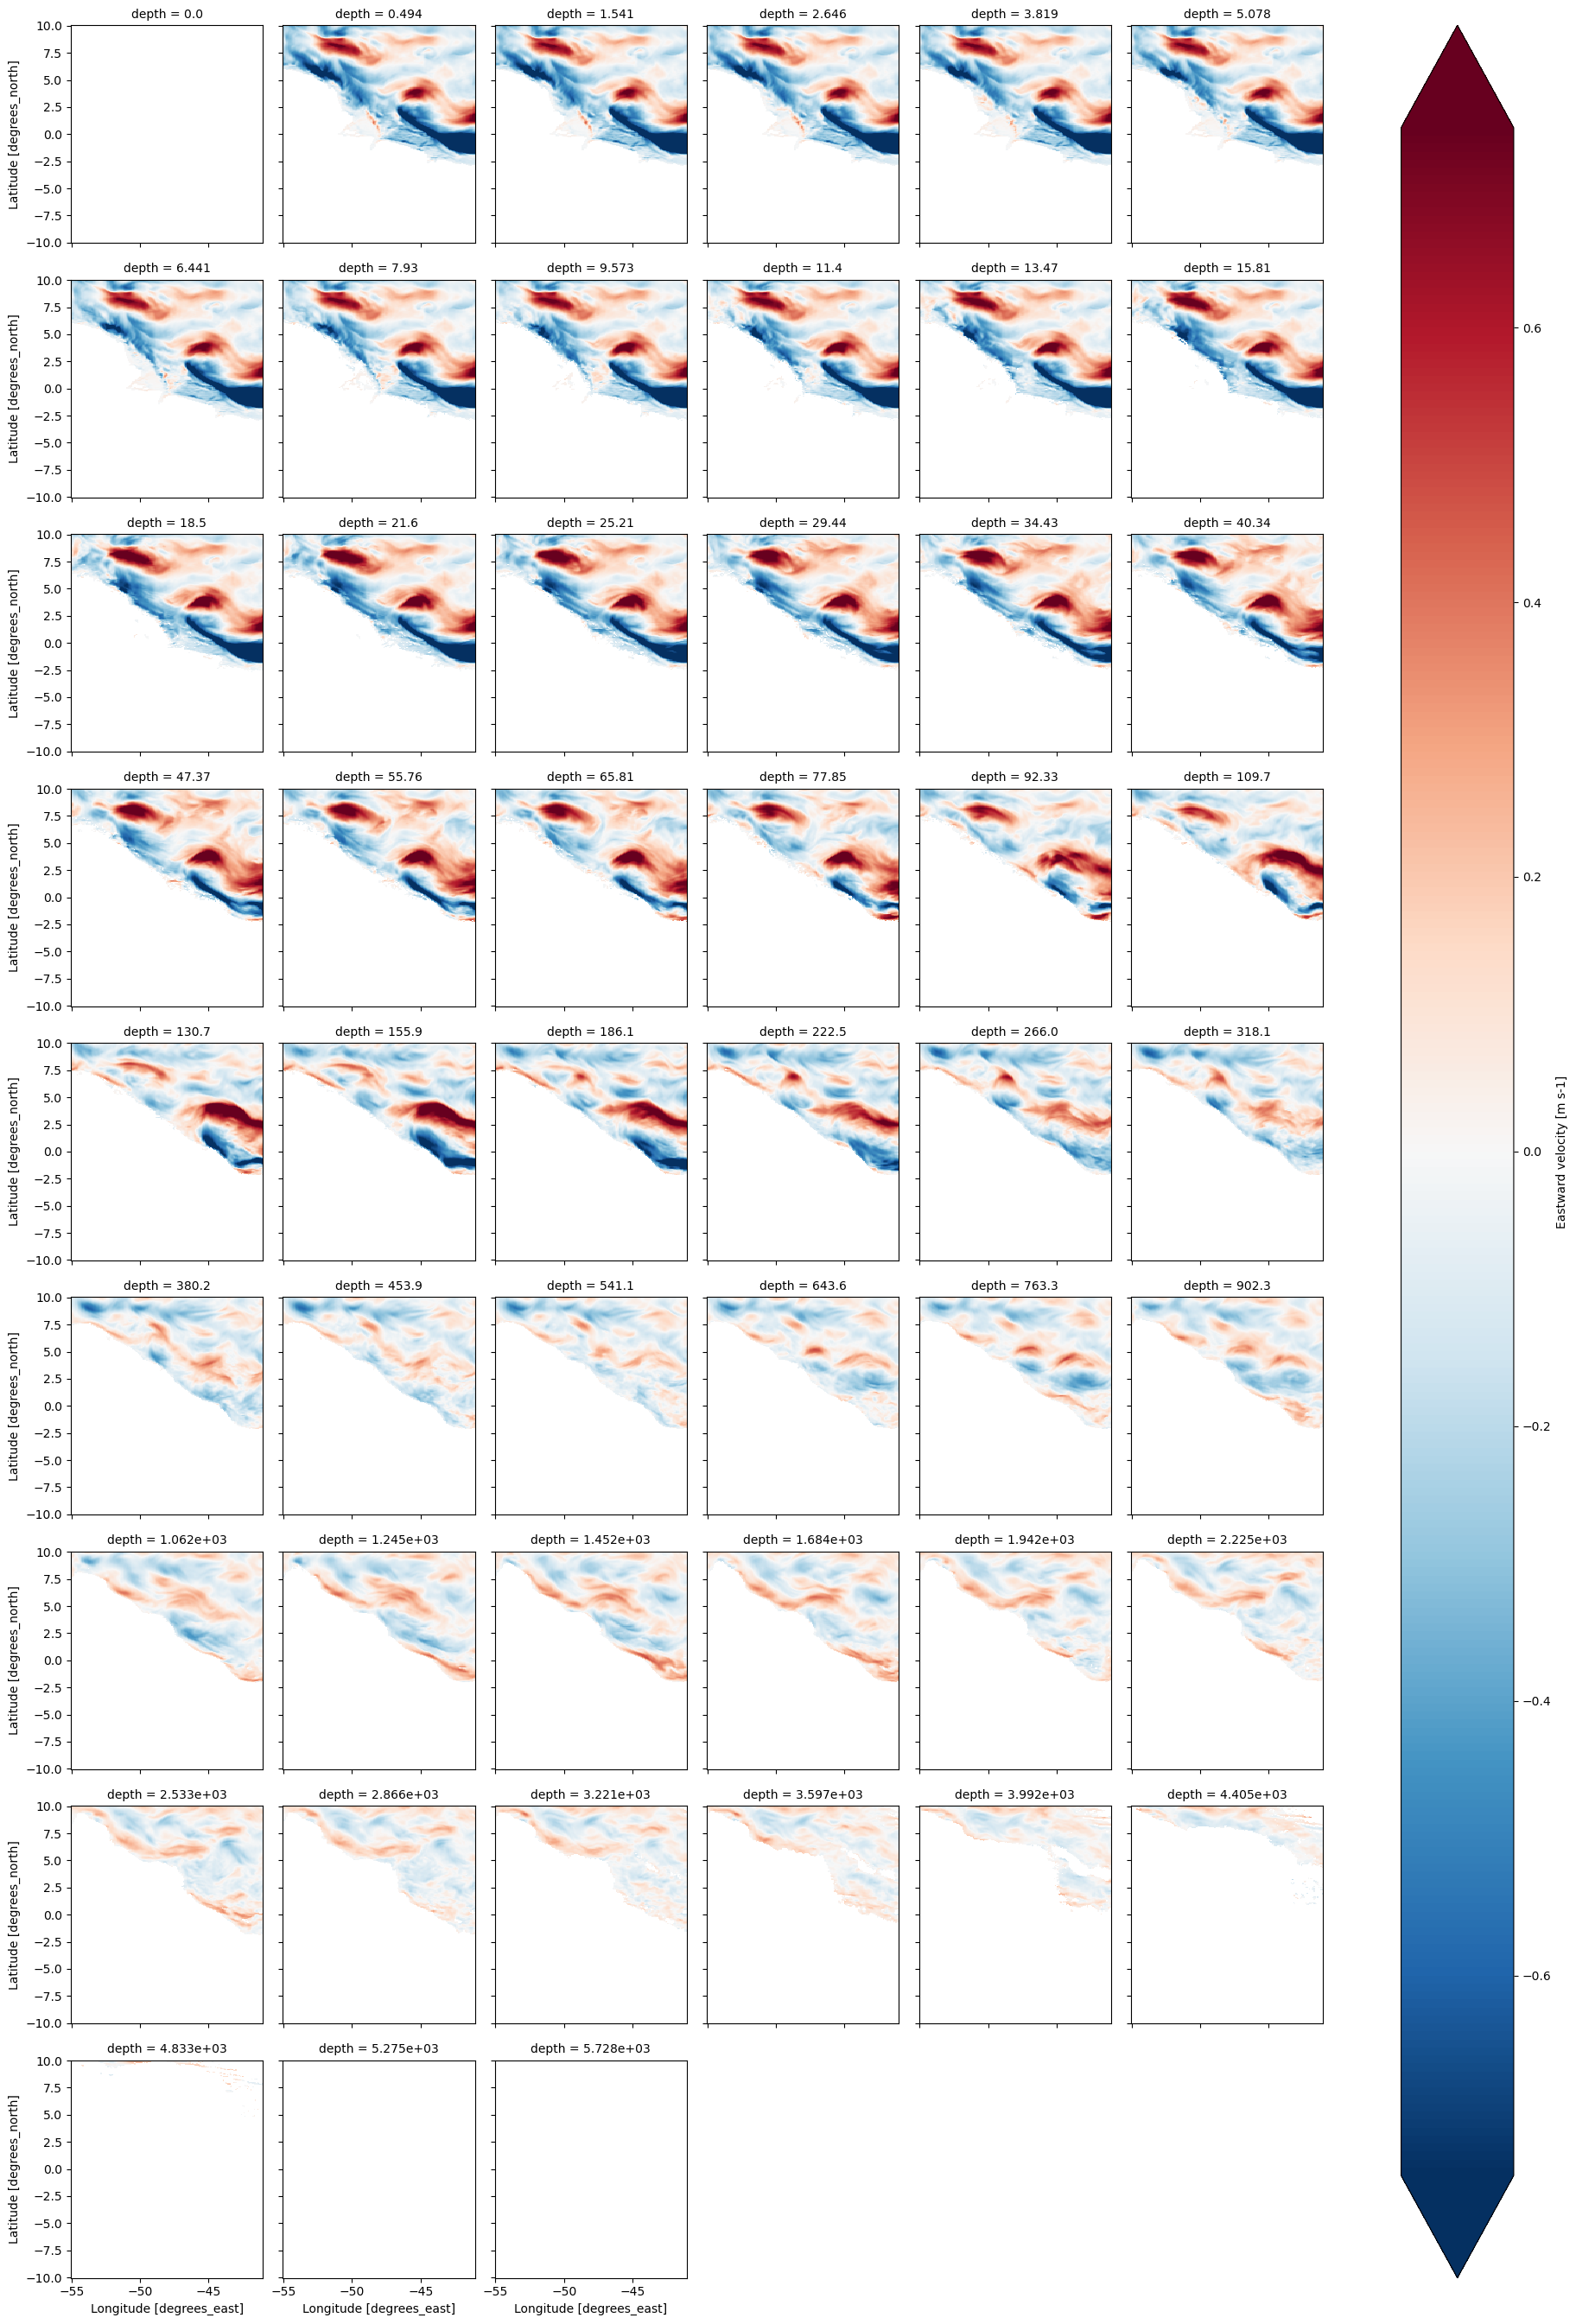

In [237]:
# #1. We insert the 0m at z
# z = np.insert(ds.depth.values,0,0.0)

# #2. We linearly interpolate the U,V
# ds= ds.interp(depth=z)
# ds['w'][..., 0, :, :] = 0
# ds['uo'][..., 0, :, :] = ds.uo.isel(depth=0)
# ds['vo'][..., 0, :, :] = ds.vo.isel(depth=0)

# ds.isel(time=0).uo.plot(x='longitude',y='latitude',col='depth',col_wrap=6, robust=True)

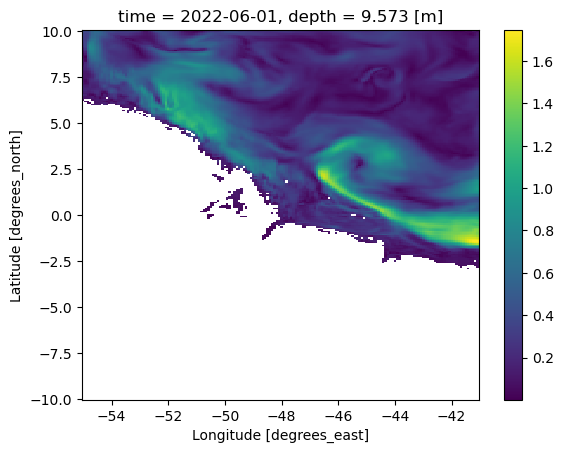

In [309]:
ref = np.sqrt(ds.uo.isel(time=0,depth=7)**2 + ds.vo.isel(time=0,depth=7)**2)
np.sqrt(ds.uo.isel(time=0,depth=7)**2 + ds.vo.isel(time=0,depth=7)**2).plot()

### C grid interpolated W

In [347]:
## Mask calculation
ds_i = ds
_lat = ds.latitude
_lon = ds.longitude
_zt = ds.depth

ds_i = ds_i.rename({"depth": "k", "latitude":"j", "longitude":"i","uo":"uf", "vo":"vf"})
ds_i = ds_i.assign_coords(
    k=np.arange(ds_i.sizes["k"]),
    j=np.arange(ds_i.sizes["j"]),
    i=np.arange(ds_i.sizes["i"]),
    depth_t=("k", _zt.data),
    latitude_f = ("j", _lat.data),
    longitude_f = ("i", _lon.data),
)


## Calculate F and T mask
ds_i = ds_i.assign(fmask = ds_i.uf.isel(time=0,drop=True).notnull())

ds_i = ds_i.assign(
    tmask=(
        ds_i.fmask.shift(i=0,j=0)
        | ds_i.fmask.shift(i=-1,j=-1).fillna(False)
        | ds_i.fmask.shift(i=0, j=-1).fillna(False)
        | ds_i.fmask.shift(i=-1,j=-1).fillna(False)
    ).astype(bool)
)

## Calculate U and V faces
ds_i = ds_i.assign(
    u=(ds_i.uf.fillna(0) + ds_i.uf.shift(j=-1).fillna(0)) /2,
    v=(ds_i.vf.fillna(0) + ds_i.vf.shift(i=-1).fillna(0)) /2,
)

## Calculate Zt
zt = ds_i.depth_t.data
zw = [zt[0]*2]


for k in range(1,50):
    zw.append((zt[k] - zw[k-1])*2 + zw[k-1])

ds_i = ds_i.assign_coords(depth_w = ("k",zw))

ds_i = ds_i.assign_coords(
    longitude_u = ds_i.longitude_f,
    latitude_v =  ds_i.latitude_f,
    
    latitude_u = ds_i.latitude_f + 1/12/2, 
    longitude_v = ds_i.longitude_f + 1/12/2,
    
    latitude_t = ds_i.latitude_f + 1/12/2, 
    longitude_t = ds_i.longitude_f + 1/12/2,
)

R = 6371e3 

ds_i = ds_i.assign_coords(
    dz_t = ds_i.depth_w - ds_i.depth_w.shift(k=1).fillna(0), 
    dx_t = np.deg2rad(1/12) * R * np.cos(np.deg2rad(ds_i.latitude_t)),
    dy_t = np.deg2rad(1/12) * R ,
    
)

## we find the total volume flux - m3
F_uv_vol = (
    ds_i.u * ds_i.dy_t * ds_i.dz_t - ds_i.u.shift(i=-1)* ds_i.dy_t * ds_i.dz_t 
    + ds_i.v * ds_i.dx_t * ds_i.dz_t - ds_i.v.shift(j=-1) * ds_i.dx_t * ds_i.dz_t
).fillna(0)

#we divide the total flux by the volume (dx*dy*dz) - 1/s
dw_by_dz = -F_uv_vol/ds_i.dx_t/ds_i.dy_t/ds_i.dz_t

w = (dw_by_dz.fillna(0) * ds_i.dz_t.fillna(0)).cumsum('k').fillna(0).where(ds_i.tmask==1)
w_bottom=w.isel(k=ds_i.tmask.sum('k')-1)
w_correct = w - w_bottom / ds_i.dz_t.where(ds_i.tmask==1).sum('k') * ds_i.depth_w

# w_correct.isel(time=0).plot(x='i',y='j',col='k',col_wrap=6, robust=True)

In [346]:
# print(w_correct.shape)
ds_i['w_c'] = w_correct
ds_i

<xarray.Dataset> Size: 2GB
Dimensions:      (time: 30, k: 50, j: 241, i: 168)
Coordinates: (12/17)
  * time         (time) datetime64[ns] 240B 2022-06-01 2022-06-02 ... 2022-06-30
  * k            (k) int64 400B 0 1 2 3 4 5 6 7 8 ... 41 42 43 44 45 46 47 48 49
  * j            (j) int64 2kB 0 1 2 3 4 5 6 7 ... 234 235 236 237 238 239 240
  * i            (i) int64 1kB 0 1 2 3 4 5 6 7 ... 161 162 163 164 165 166 167
    depth_t      (k) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
    latitude_f   (j) float32 964B -10.0 -9.917 -9.833 -9.75 ... 9.833 9.917 10.0
    ...           ...
    longitude_v  (i) float32 672B -54.96 -54.87 -54.79 ... -41.21 -41.12 -41.04
    latitude_t   (j) float32 964B -9.958 -9.875 -9.792 ... 9.875 9.958 10.04
    longitude_t  (i) float32 672B -54.96 -54.87 -54.79 ... -41.21 -41.12 -41.04
    dz_t         (k) float32 200B 0.988 1.107 1.102 1.246 ... 435.3 447.7 458.6
    dx_t         (j) float64 2kB 9.127e+03 9.129e+03 ... 9.127e+03 9.124e+03
    dy_t         float64 8B 9.266e+03
Data variables:
    uf           (time, k, j, i) float32 243MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    vf           (time, k, j, i) float32 243MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    w            (time, k, j, i) float32 243MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    fmask        (k, j, i) bool 2MB True True True True ... True True True True
    tmask        (k, j, i) bool 2MB True True True True ... True True True True
    u            (time, k, j, i) float32 243MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    v            (time, k, j, i) float32 243MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    w_c          (time, k, j, i) float64 486MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    Conventions:       CF-1.11
    title:             daily mean fields from Global Ocean Physics Analysis a...
    institution:       Mercator Ocean International
    producer:          CMEMS - Global Monitoring and Forecasting Centre
    source:            MOI GLO12
    credit:            E.U. Copernicus Marine Service Information (CMEMS)
    contact:           https://marine.copernicus.eu/contact
    references:        http://marine.copernicus.eu
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  GLOBAL_ANALYSISFORECAST_PHY_001_024
    subset:datasetId:  cmems_mod_glo_phy-cur_anfc_0.083deg_P1D-m_202406
    subset:date:       2025-07-09T14:59:21.915Z

## Particles 

#### Release section in the Plume

The rotation matrix is:

$$
\begin{bmatrix}
x' \\
y'
\end{bmatrix}
=
\begin{bmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{bmatrix}
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

where $\theta = 45^\circ$.


In [285]:
lon = -48.9 * np.ones(shape=(num_particles, ))
lat = np.linspace(1.5, -1, num_particles)

# 1. Center
lon0 = lon.mean()
lat0 = lat.mean()

# 2. Centered coordinates
x = lon - lon0
y = lat - lat0

# 3. Rotation
theta = np.deg2rad(45)
x_rot = x * np.cos(theta) - y * np.sin(theta)
y_rot = x * np.sin(theta) + y * np.cos(theta)

# 4. Back to lon/lat
lon_start = x_rot + lon0
lat_start = y_rot + lat0

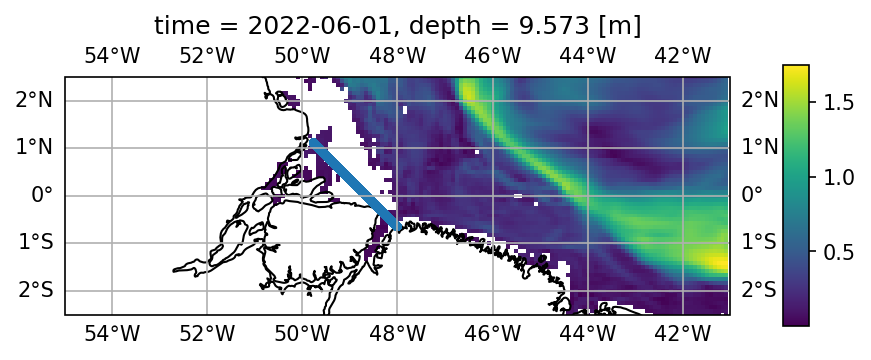

In [310]:
fig, ax = plt.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
fig.set_dpi(150)

ax.plot(lon_start,lat_start,marker='.')
im = ref.plot(ax=ax, transform=ccrs.PlateCarree(), add_colorbar=False)

ax.coastlines()
ax.set_extent([
    -55,
    -41,
    -2.5,
    2.5,
])
ax.gridlines(draw_labels=True);

cbar = plt.colorbar(im, ax=ax, orientation="vertical", fraction=0.035, pad=0.07,aspect=10)

#### Particle Run GLORYS

In [ ]:
## parameters
## set the number of particles
num_particles = 10000

## set the tracking time
days = 10
minutes = 10

## record the particles every timestep of
hours=1

## now the fieldset
fieldset = FieldSet.from_xarray_dataset(
    ds,
    variables = {"U": "uo",
                 "V": "vo",
                 "W": "w"},
    dimensions={'lon':'longitude',
                'lat':'latitude',
                'time':'time',
               'depth': "depth"
               },
)

##check the error
def CheckError(particle, fieldset, time):
    if particle.state >= 50:  # This captures all Errors
        particle.delete()

## Time and depth initial conditios
time_origin=np.array([str(fieldset.time_origin)],dtype='datetime64[ns]')
time = np.repeat(time_origin, num_particles)  # Assign the same time to all particles
depth = np.random.uniform(0,20, size=num_particles)  # Choose random depths

# initiate pset
pset = ParticleSet(
    fieldset=fieldset,
    lon = lon_start,
    lat = lat_start,
    depth=depth,
    time=time
) 

rnd=str(np.random.randint(1234))

out_path = '../data/' #path to store the particle zarr
out_fn = 'Parcels_run_'+rnd

output_file = pset.ParticleFile(name=out_path+out_fn, 
                                outputdt=timedelta(hours=hours))

In [314]:
## Execute particles
pset.execute(
    [AdvectionRK4_3D,CheckError],
    runtime=timedelta(days=days),
    dt=timedelta(minutes=minutes),
    output_file= output_file
)

INFO: Output files are stored in ../data/Parcels_run_620.zarr.
100%|██████████| 864000.0/864000.0 [03:13<00:00, 4472.42it/s]


### Plotting

In [274]:
from cmocean import cm # for oceanography-specific colormaps
from itertools import zip_longest
from functools import reduce
from operator import add
from pathlib import Path
import tqdm
from xhistogram.xarray import histogram as xhist
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [315]:
ds_traj = xr.open_zarr(out_path+out_fn+'.zarr')
ds_traj = ds_traj.compute()
ds_traj

<xarray.Dataset> Size: 48MB
Dimensions:     (trajectory: 10000, obs: 241)
Coordinates:
  * obs         (obs) int32 964B 0 1 2 3 4 5 6 7 ... 234 235 236 237 238 239 240
  * trajectory  (trajectory) int64 80kB 43026 43047 43062 ... 52997 52998 52999
Data variables:
    lat         (trajectory, obs) float32 10MB 1.129 nan nan ... -0.6664 nan
    lon         (trajectory, obs) float32 10MB -49.78 nan nan ... -47.91 nan
    time        (trajectory, obs) datetime64[ns] 19MB 2022-06-01 NaT ... NaT
    z           (trajectory, obs) float32 10MB 0.4168 nan nan ... 6.691 nan
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

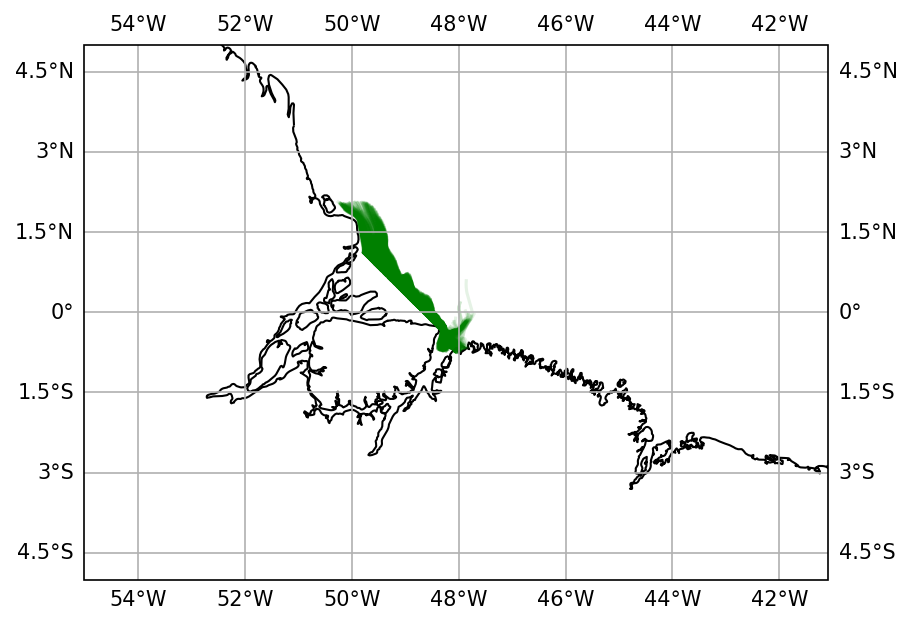

In [316]:
# figure,ax = plt.subplots(1,1,figsize=(7,5))
fig, ax = plt.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
fig.set_dpi(150)

for n in range(ds_traj.sizes["trajectory"]):
    ax.plot(
        *ds_traj.isel(trajectory=n)[["lon", "lat"]].dropna("obs").data_vars.values(),
        color="g", alpha=0.1,
        transform=ccrs.PlateCarree(),
    )

ax.coastlines()
ax.set_extent([
    np.min(fieldset.U.grid.lon),
    np.max(fieldset.U.grid.lon),
    -5,
    5,
])
ax.gridlines(draw_labels=True);

# for t in np.random.randint(0,1000,size=(100,)):
#     plt.plot(ds_traj.isel(trajectory=t).lon, ds_traj.isel(trajectory=t).lat,'k-',alpha=0.5)

# plt.title('Glorys')
# plt.grid(True)

In [317]:
lon_bins = np.linspace(ds_traj.lon.min().compute().data[()], ds_traj.lon.max().compute().data[()], 30*2)
lat_bins = np.linspace(ds_traj.lat.min().compute().data[()], ds_traj.lat.max().compute().data[()], 40*2)

obs_counts = xhist(
    ds_traj.lon,
    ds_traj.lat,
    bins=[lon_bins, lat_bins],
    dim=["trajectory", ],
    bin_dim_suffix=""
)

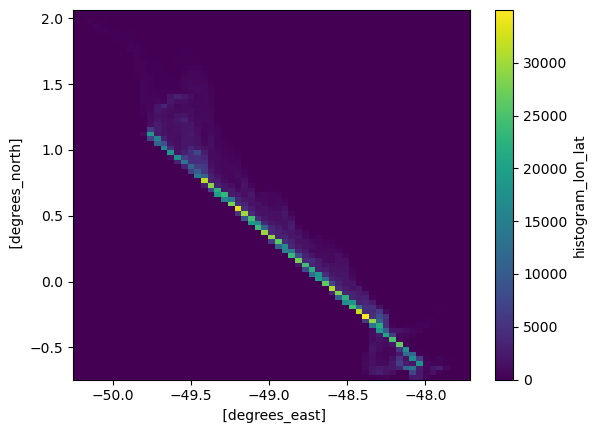

In [318]:
obs_counts.sum('obs').plot(x='lon',y='lat')

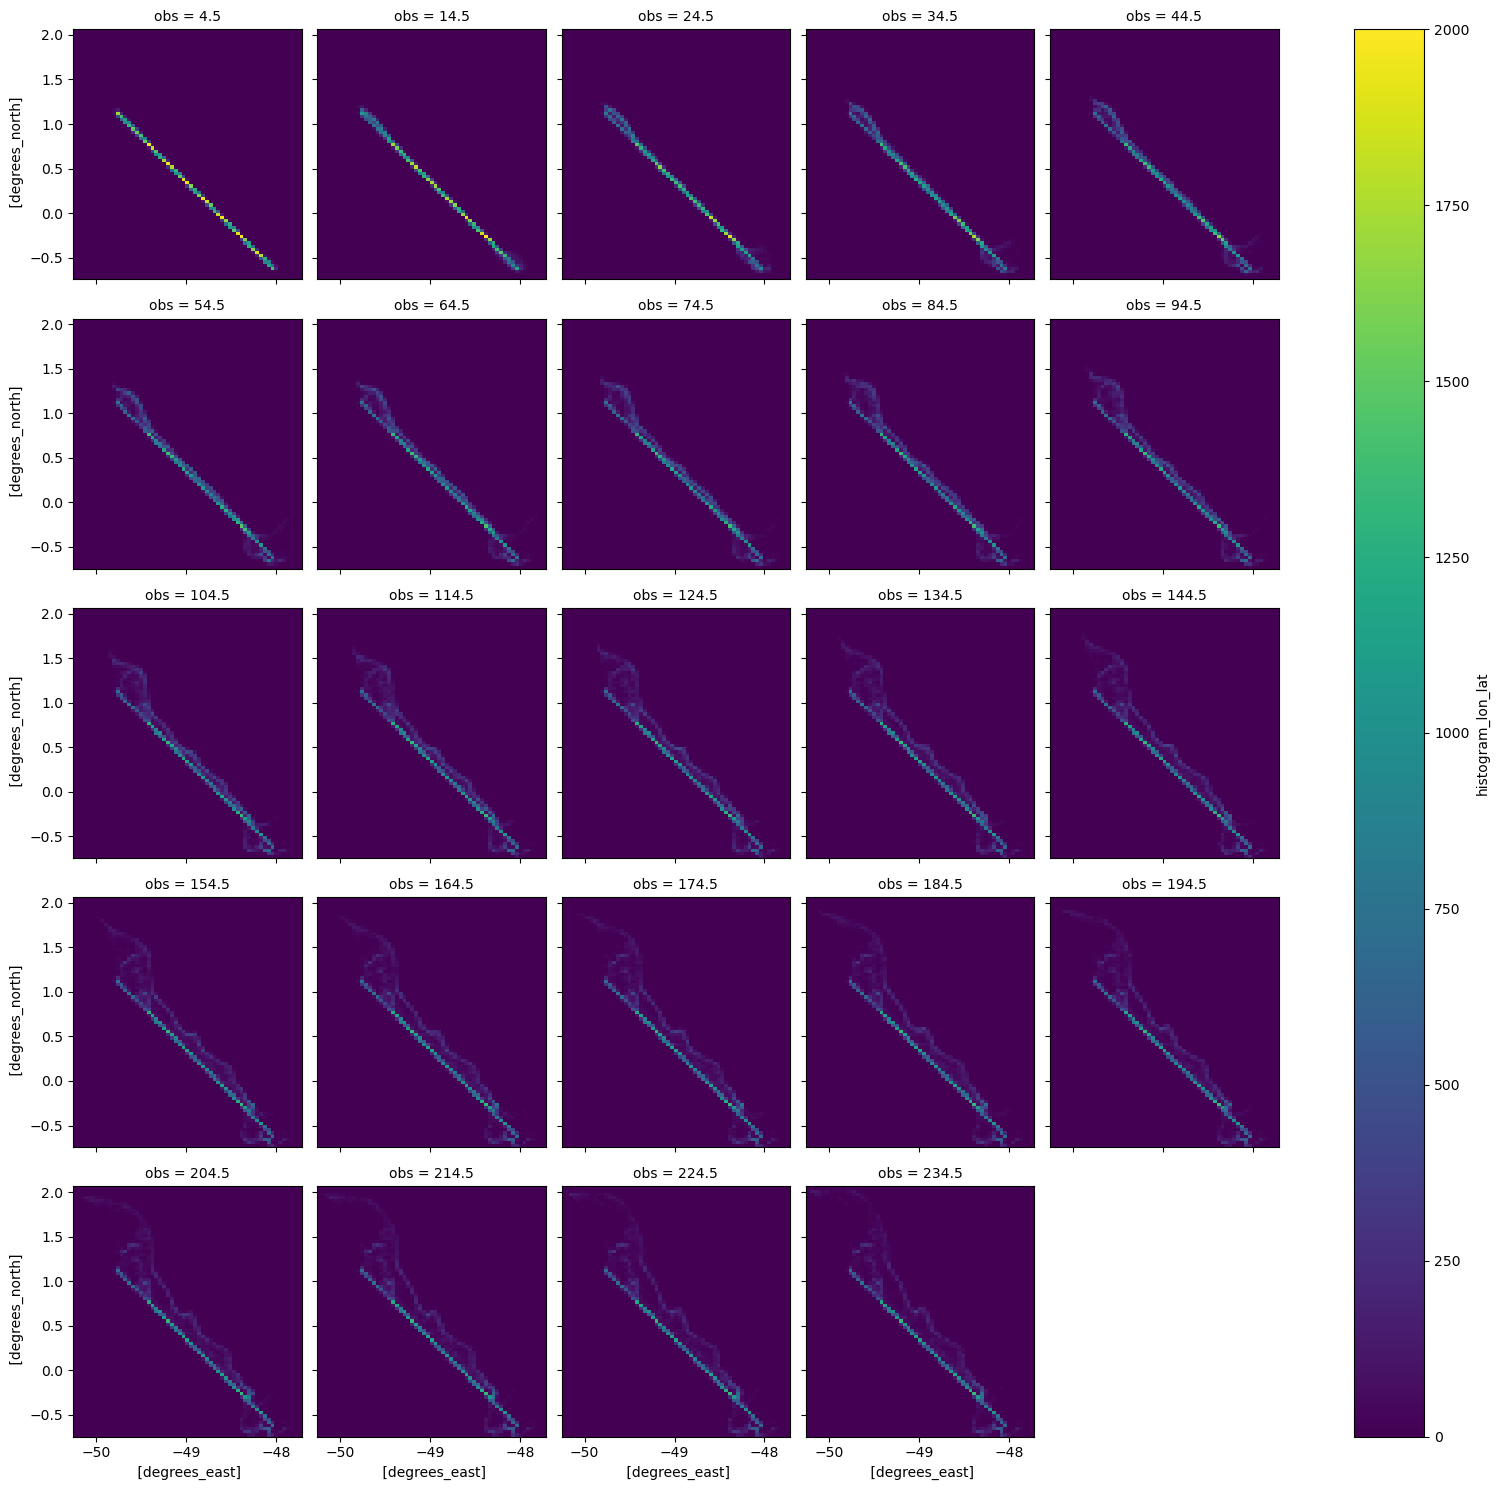

In [319]:
obs_counts.coarsen(obs=10, boundary="trim").sum().plot(x="lon", y="lat", col="obs", col_wrap=5)